# Determination of the Specific Charge of the Electron

This notebook analyzes the motion of electrons in a uniform magnetic field and determines the specific charge (e/m) of the electron using experimental data.

## Theoretical Background
When an electron is accelerated by a potential difference, it gains kinetic energy:

$$ \frac{1}{2} m v^2 = e U $$

In a uniform magnetic field, the electron follows a circular trajectory due to the Lorentz force:

$$ F = e v B = \frac{m v^2}{r} $$

From these equations, we derive the expression for the specific charge (e/m):

$$ \frac{e}{m} = \frac{2U}{r^2 B^2} $$


## Experimental Setup

![Experimental Setup](imgs/setup.png)

- A glass tube filled with low-pressure neon contains an electron gun.
- The electrons are accelerated through a known potential difference.
- A pair of Helmholtz coils generate a nearly uniform magnetic field.
- The electron trajectory is observed as a glowing circular path in the neon gas.


## Data Analysis
Using the collected experimental data, we calculate the specific charge (e/m) by measuring the electron's trajectory radius and magnetic field strength.

We will visualize the data and fit it to theoretical expectations.

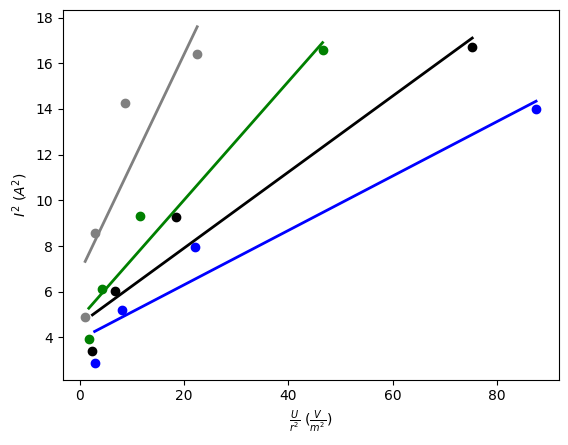

Slope for r = 5: 0.11909651176696898
Slope for r = 4: 0.1664255191114188
Slope for r = 3: 0.259416173488697
Slope for r = 2: 0.47822865676638127

Computed e/m values:
e/m for r = 5: [35031587.20784216]
e/m for r = 4: [25069111.15789402]
e/m for r = 3: [16082805.40880061]
e/m for r = 2: [8724152.72293584]


In [5]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.linear_model import LinearRegression

# Constants
u_0 = 4 * np.pi * 10 ** (-7)  # Vacuum permeability
n = 154  # Number of turns in Helmholtz coils
R = 0.2  # Radius of coils in meters

# Load experimental current (I) data
I = np.genfromtxt("data/result.csv", delimiter=",", skip_header=1)
I = I[:, 1:]

# Given voltage (U) values and radius (r)
U_values = [160, 180, 200, 220, 240, 260, 280]
r_values = [5, 4, 3, 2]

# Compute squared radius values
r_squared = [r ** 2 for r in r_values]

# Compute I^2
I_squared = I ** 2

# Compute U/r^2 for each combination
U_r = [U / r_sq for U in U_values for r_sq in r_squared]

# a = I^2/U_r
a = []
for i in range(0, len(I_squared)):
    a = np.append(a, I_squared[i] / U_r[i])

# x = a*U_r
x = a * U_r

# Flatten and round values for better readability
I_squared = np.round(I_squared.flatten(), 3).tolist()
x_values = np.round(x, 3).tolist()

# Organizing data into separate lists for different radii
I_squared_sets = [I_squared[i * 4:(i + 1) * 4] for i in range(len(r_values))]
x_sets = [x_values[i * 4:(i + 1) * 4] for i in range(len(r_values))]

# Convert x values to NumPy arrays for linear regression
x_sets = [np.array(x).reshape((-1, 1)) for x in x_sets]

# Perform linear regression for each radius
models = [LinearRegression().fit(x_sets[i], I_squared_sets[i]) for i in range(len(r_values))]

# Plotting regression lines and data points
colors = ['blue', 'black', 'green', 'gray']
for i, color in enumerate(colors):
    plt.plot(x_sets[i], models[i].predict(x_sets[i]), color=color, linewidth=2)
    plt.scatter(x_sets[i], I_squared_sets[i], color=color, marker="o")

plt.xlabel(r"$\frac{U}{r^2}\ (\frac{V}{m^2})$")
plt.ylabel(r"$I^2\ (A^2)$")
plt.show()


# Printing slopes of regression lines
for i, model in enumerate(models):
    print(f"Slope for r = {r_values[i]}: {model.coef_[0]}")

# Calculate e/m ratio for each radius
e_m_values = [
    (125 * R ** 2) / (u_0 ** 2 * n ** 2 * models[i].coef_ * 32)
    for i in range(len(r_values))
]

print("\nComputed e/m values:")
for i, e_m in enumerate(e_m_values):
    print(f"e/m for r = {r_values[i]}: {e_m}")
